# Clustering data email

[nltk_data] Downloading package punkt to C:\Users\Mukti
[nltk_data]     Hendra\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Mukti
[nltk_data]     Hendra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


📊 Jumlah data: 5572
   id                                               Text Unnamed: 2  \
0   1  Go until jurong point, crazy.. Available only ...        NaN   
1   2                      Ok lar... Joking wif u oni...        NaN   
2   3  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   4  U dun say so early hor... U c already then say...        NaN   
4   5  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

✅ Contoh hasil preprocessing:
   id                                         clean_text
0   1  go jurong point crazi avail bugi n great world...
1   2                              ok lar joke wif u oni
2   3  free entri wkli comp win fa cup final tkt st m...
3   4                u dun say earli hor u c alreadi say
4   5          nah dont think goe usf live around though

   id  abiola  abl  abt

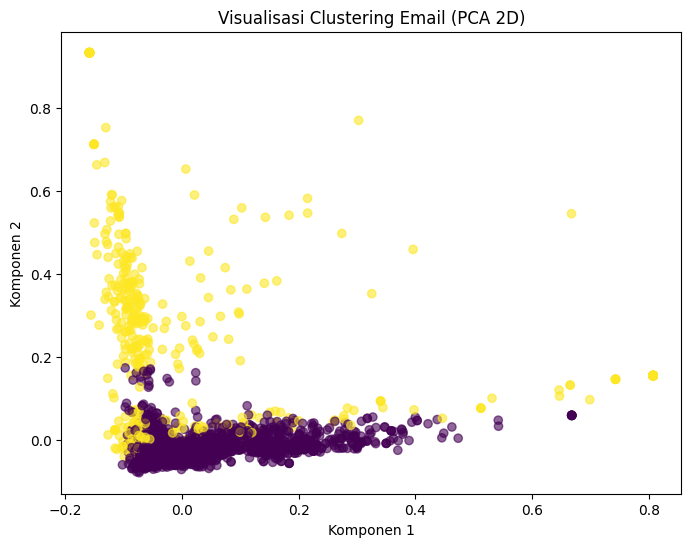


📂 Contoh isi Cluster 0
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat......

2. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's...

3. U dun say so early hor... U c already then say......


📂 Contoh isi Cluster 1
1. Ok lar... Joking wif u oni......

2. Aft i finish my lunch then i go str down lor. Ard 3 smth lor. U finish ur lunch already?...

3. Yup... Ok i go home look at the timings then i msg Ì_ again... Xuhui going to learn on 2nd may too but her lesson is at 8am...


💾 Hasil clustering disimpan ke 'hasil_clustering_email.csv'


In [11]:

# Import library
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('stopwords')

#  Load data
df = pd.read_csv("spam.csv", encoding='latin-1')
print("📊 Jumlah data:", len(df))
print(df.head())

# Pastikan kolom sesuai
df = df[['id', 'Text']]
df.columns = ['id', 'email_text']

# 3️⃣ Preprocessing teks
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)                       
    text = text.translate(str.maketrans('', '', string.punctuation))  
    text = re.sub(r'\s+', ' ', text).strip()             
    return text

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text):
    text = clean_text(text)
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['email_text'].astype(str).apply(preprocess)

print("\n✅ Contoh hasil preprocessing:")
print(df[['id', 'clean_text']].head())

# 4️⃣ Ekstraksi fitur dengan TF-IDF
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['clean_text'])
print("")
feature_names = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(X.toarray(), columns=feature_names)

# Gabungkan langsung dengan kolom id (dan teks jika ingin)
tfidf_matrix = pd.concat([df[['id']], tfidf_df], axis=1)

print(tfidf_matrix.head())
tfidf_matrix.to_csv("tfidf_matrix.csv", index=False)
print("\n💾 Matriks TF-IDF disimpan ke 'tfidf_matrix_full.csv'")


print("\n🔢 Bentuk matriks TF-IDF:", X.shape)

#  Clustering dengan K-Means
k = 2  
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X)

df['cluster'] = clusters

# Evaluasi dengan Silhouette Score
sil_score = silhouette_score(X, clusters)
print(f"\n📈 Silhouette Score: {sil_score:.4f}")

# Visualisasi hasil clustering dengan PCA
pca = PCA(n_components=2, random_state=42)
reduced_X = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,6))
plt.scatter(reduced_X[:,0], reduced_X[:,1], c=clusters, cmap='viridis', alpha=0.6)
plt.title('Visualisasi Clustering Email (PCA 2D)')
plt.xlabel('Komponen 1')
plt.ylabel('Komponen 2')
plt.show()

# Analisis isi tiap cluster
for i in range(k):
    print(f"\n==============================")
    print(f"📂 Contoh isi Cluster {i}")
    print("==============================")
    sample = df[df['cluster'] == i]['email_text'].head(3).values
    for j, text in enumerate(sample, 1):
        print(f"{j}. {text[:200]}...\n")

# 9️⃣ Simpan hasil ke file CSV
df.to_csv("hasil_clustering_email.csv", index=False)
print("\n💾 Hasil clustering disimpan ke 'hasil_clustering_email.csv'")
